In [33]:
import pandas as pd
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings('ignore')

np.random.seed(42)


BASE_PATH = Path("..").resolve()
RAW_DATA_PATH = BASE_PATH / "data" / "raw" / "dataset_elpino.csv"
PROCESSED_DATA_PATH = BASE_PATH / "data" / "processed" / "elpino_categories.csv"


if not RAW_DATA_PATH.exists():
    for parent in [BASE_PATH, *BASE_PATH.parents]:
        candidate_raw = parent / "data" / "raw" / "dataset_elpino.csv"
        candidate_processed = parent / "data" / "processed" / "elpino_categories.csv"

        if candidate_raw.exists():
            BASE_PATH = parent
            RAW_DATA_PATH = candidate_raw
            PROCESSED_DATA_PATH = candidate_processed
            break
    else:
        raise FileNotFoundError(f"Archivo no encontrado: {RAW_DATA_PATH}")

print(f"Ruta de datos verificada: {RAW_DATA_PATH}")
print(f"Ruta de salida: {PROCESSED_DATA_PATH}")

Ruta de datos verificada: C:\Desarrollo\Proyectos\Activos\clinical-grd-classification\data\raw\dataset_elpino.csv
Ruta de salida: C:\Desarrollo\Proyectos\Activos\clinical-grd-classification\data\processed\elpino_categories.csv


---
# Cargar el dataset

In [34]:
df = pd.read_csv(f'{BASE_PATH}/data/raw/dataset_elpino.csv', sep=';')
df.head()

,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Diag 03 Secundario (cod+des),Diag 04 Secundario (cod+des),Diag 05 Secundario (cod+des),Diag 06 Secundario (cod+des),Diag 07 Secundario (cod+des),Diag 08 Secundario (cod+des),Diag 09 Secundario (cod+des),Diag 10 Secundario (cod+des),...,Proced 24 Secundario (cod+des),Proced 25 Secundario (cod+des),Proced 26 Secundario (cod+des),Proced 27 Secundario (cod+des),Proced 28 Secundario (cod+des),Proced 29 Secundario (cod+des),Proced 30 Secundario (cod+des),Edad en años,Sexo (Desc),GRD
0,A41.8 - Otras septicemias especificadas,B37.6 - Endocarditis debida a candida (I39.8*),"I39.8 - Endocarditis, válvula no especificada,...",N10 - Nefritis tubulointersticial aguda,B96.1 - Klebsiella pneumoniae [K. pneumoniae] ...,L89.9 - Úlcera de decúbito y area de presión n...,L08.9 - Infección local de la piel y del tejid...,B96.2 - Escherichia coli [E. coli] como causa ...,A41.5 - Sepsis por otros organnismos Gram nega...,J86.9 - Piotórax sin fístula,...,99.84 - AISLAMIENTO,88.72 - ECOCARDIOGRAFIA,90.42 - EXAMEN MICROSCOPICO RESPIRATORIO.CULTIVO,90.52 - EXAMEN MICROSCOPICO SANGRE.CULTIVO,91.39 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,91.33 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,87.03 - TOMOGRAFIA AXIAL COMPUTERIZADA CABEZA,40,Hombre,184103 - MH SEPTICEMIA W/MCC
1,"U07.1 - COVID-19, virus identificado",J12.8 - Neumonía debida a otros virus,R06.0 - Disnea,R05 - Tos,"R50.9 - Fiebre, no especificada",Z29.0 - Aislamiento,Z01.7 - Examen de laboratorio,"J96.00 - Insuficiencia respiratoria aguda, Tip...",J94.2 - Hemotórax,J92.9 - Paquipleuritis sin asbestosis,...,91.62 - EXAMEN MICROSCOPICO PIEL.CULTIVO,90.43 - EXAMEN MICROSCOPICO RESPIRATORIO.CULTI...,91.39 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,90.52 - EXAMEN MICROSCOPICO SANGRE.CULTIVO,91.32 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,96.59 - IRRIGACION HERIDA OTRA,90.99 - EXAMEN MICROSCOPICO DIGESTIVO INFERIOR...,53,Hombre,041013 - PH ECMO VENTILACIÓN MECÁNICA PROLONGA...
2,K56.5 - Adherencias [bridas] intestinales con ...,R57.2 - Shock séptico,R57.1 - Choque hipovolémico,J80 - Síndrome de dificultad respiratoria del ...,Y95 - Afección nosocomial,J15.0 - Neumonía debida a Klebsiella pneumoniae,U82.2 - Resistencia a Betalactamasas de amplio...,B95.6 - Staphylococcus aureus como causa de en...,B96.8 - Otros agentes bacterianos especificado...,B37.1 - Candidiasis pulmonar,...,99.84 - AISLAMIENTO,91.73 - EXAMEN MICROSCOPICO HERIDA OPERATORIA....,90.53 - EXAMEN MICROSCOPICO SANGRE.CULTIVO Y S...,99.26 - INYECCION TRANQUILIZANTE,89.39 - OTRAS MEDICIONES Y EXAMENES NO QUIRURG...,89.66 - GASOMETRIA VENA,89.65 - GASOMETRIA ARTERIA,65,Hombre,041013 - PH ECMO VENTILACIÓN MECÁNICA PROLONGA...
3,K76.8 - Otras enfermedades especificadas del h...,K66.1 - Hemoperitoneo,"N18.5 - Enfermedad renal crónica, estadio 5",D64.9 - Anemia de tipo no especificado,E87.5 - Hiperpotasemia,E87.2 - Acidosis,J81 - Edema pulmonar,N17.8 - Otras insuficiencias renales agudas,J44.9 - Enfermedad pulmonar obstructiva crónic...,R41.0 - Desorientación no especificada,...,57.94 - SONDAJE URINARIO PERMANENTE,00.13 - INYECCION NESIRITIDE,00.17 - INFUSON AGENTE VASOPRESOR,99.04 - TRANSFUSION CONCENTRADO HEMATIES,99.18 - INYECCION ELECTROLITO,99.21 - INYECCION ANTIBIOTICO,99.23 - INYECCION ESTEROIDE,61,Hombre,041023 - PH VENTILACIÓN MECÁNICA PROLONGADA SI...
4,T81.0 - Hemorragia y hematoma que complican un...,"Y83.2 - Operación quirúrgica con anastomosis, ...",S31.1 - Herida de la pared abdominal,S36.80 - Traumatismo de otros órganos intraabd...,W31.62 - Contacto traumático con otras maquina...,"J96.09 - Insuficiencia respiratoria aguda, Tip...",J15.0 - Neumonía debida a Klebsiella pneumoniae,U82.2 - Resistencia a Betalactamasas de amplio...,"U07.1 - COVID-19, virus identificado","N39.0 - Infección de vías urinarias, sitio no ...",...,90.52 - EXAMEN MICROSCOPICO SANGRE.CULTIVO,91.39 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,91.32 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,93.

---
## 

Tipos de datos: 


,tipo
Diag 01 Principal (cod+des),str
Diag 02 Secundario (cod+des),str
Diag 03 Secundario (cod+des),str
Diag 04 Secundario (cod+des),str
Diag 05 Secundario (cod+des),str
...,...
Proced 29 Secundario (cod+des),str
Proced 30 Secundario (cod+des),str
Edad en años,int64
Sexo (Desc),str


,cardinalidad
Proced 01 Principal (cod+des),528
Proced 02 Secundario (cod+des),496
Proced 03 Secundario (cod+des),385
Proced 04 Secundario (cod+des),287
Proced 05 Secundario (cod+des),259
Proced 06 Secundario (cod+des),246
Proced 07 Secundario (cod+des),223
Proced 08 Secundario (cod+des),214
Proced 09 Secundario (cod+des),209
Proced 10 Secundario (cod+des),196


Procedimiento con mayor cardinalidad: Proced 01 Principal (cod+des)
Cardinalidad: 528

 Valores faltantes por columna


,Valores faltantes
Diag 01 Principal (cod+des),0
Diag 02 Secundario (cod+des),0
Diag 03 Secundario (cod+des),0
Diag 04 Secundario (cod+des),0
Diag 05 Secundario (cod+des),0
...,...
Proced 29 Secundario (cod+des),0
Proced 30 Secundario (cod+des),0
Edad en años,0
Sexo (Desc),0


...

,conteo
GRD,
146101 - PH CESÁREA,813
"146121 - PH PARTO VAGINAL CON PROCED., EXCEPTO ESTERILIZACIÓN Y/O DILATACIÓN Y LEGRADO",639
146131 - PH PARTO VAGINAL,538
"158171 - MH NEONATO, PESO AL NACER >2499 GR SIN PROCEDIMIENTO MAYOR",389
134161 - MH TRASTORNOS DEL ANTEPARTO,325



Clases con conteo menor a 10: 297


,conteo
GRD,
014131 - MH HEMORRAGIA INTRACRANEAL NO TRAUMÁTICA,9
164141 - MH OTROS TRASTORNOS DE LA SANGRE Y ÓRGANOS HEMATOPOYÉTICOS,9
124112 - MH ENF. DEL APARATO REPRODUCTOR MASCULINO EXCEPTO NEOPLASIA W/CC,9
121131 - PH PROCEDIMIENTOS SOBRE PRÓSTATA Y ESCROTO NO COMPLEJOS,9
"034151 - MH OTROS DIAGNÓSTICOS SOBRE OÍDO, NARIZ, BOCA Y GARGANTA",9
...,...
164142 - MH OTROS TRASTORNOS DE LA SANGRE Y ÓRGANOS HEMATOPOYÉTICOS W/CC,1
"101202 - PH PROCEDIMIENTOS SOBRE TIROIDES, PARATIROIDES Y CONDUCTO TIROGLOSO W/CC",1
134101 - MH NEOPLASIA DEL APARATO REPRODUCTOR FEMENINO,1



Clases con conteo mayor a 100: 32


,conteo
GRD,
146101 - PH CESÁREA,813
"146121 - PH PARTO VAGINAL CON PROCED., EXCEPTO ESTERILIZACIÓN Y/O DILATACIÓN Y LEGRADO",639
146131 - PH PARTO VAGINAL,538
"158171 - MH NEONATO, PESO AL NACER >2499 GR SIN PROCEDIMIENTO MAYOR",389
134161 - MH TRASTORNOS DEL ANTEPARTO,325
071141 - PH COLECISTECTOMÍA LAPAROSCÓPICA,317
044153 - MH INFECCIONES E INFLAMACIONES RESPIRATORIAS W/MCC,287
061131 - PH PROCEDIMIENTOS SOBRE APÉNDICE,252
041023 - PH VENTILACIÓN MECÁNICA PROLONGADA SIN TRAQUEOSTOMÍA W/MCC,248


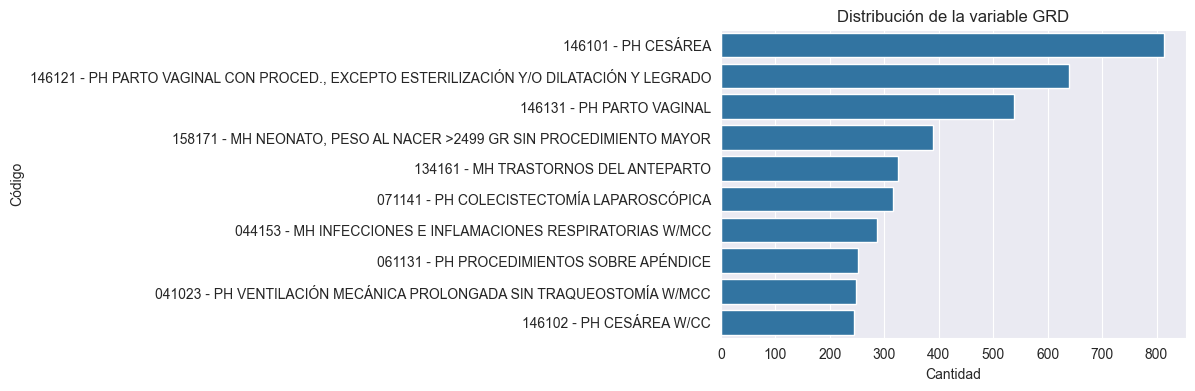

Total clases: 526
Clases en cola larga (< 1.0%): 509
Peso total de la cola larga: 62.66%


,conteo,pct,pct_acum
GRD,,,
146101,813,0.055834,0.055834
146121,639,0.043884,0.099718
146131,538,0.036948,0.136666
158171,389,0.026715,0.163382
134161,325,0.022320,0.185702
071141,317,0.021770,0.207472
044153,287,0.019710,0.227182
061131,252,0.017307,0.244489
041023,248,0.017032,0.261520


,conteo,pct,pct_acum
GRD,,,
044183,145,0.009958,0.383353
146132,140,0.009615,0.392968
131301,139,0.009546,0.402514
114121,136,0.009340,0.411854
044213,135,0.009271,0.421125
094131,134,0.009203,0.430328
041203,130,0.008928,0.439256
071142,129,0.008859,0.448115
214121,123,0.008447,0.456562


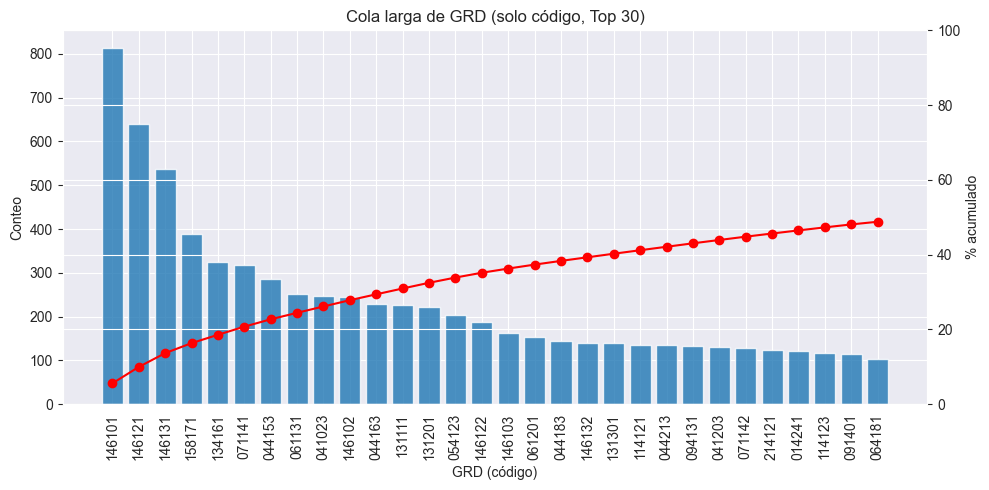


Columnas categóricas - Top 5 valores:


,Diag 01 Principal (cod+des),conteo
0,O70.0 - Desgarro perineal de primer grado dura...,779
1,"O80.0 - Parto único espontáneo, presentación c...",471
2,"U07.1 - COVID-19, virus identificado",327
3,O34.2 - Atención materna por cicatriz uterina ...,304
4,E11.5 - Diabetes mellitus tipo 2 con complicac...,215


,Diag 02 Secundario (cod+des),conteo
0,-,1209
1,I10 - Hipertensión esencial (primaria),828
2,"O80.0 - Parto único espontáneo, presentación c...",704
3,"J96.09 - Insuficiencia respiratoria aguda, Tip...",369
4,J12.8 - Neumonía debida a otros virus,332


,Diag 03 Secundario (cod+des),conteo
0,-,2687
1,I10 - Hipertensión esencial (primaria),664
2,"Z37.0 - Nacido vivo, único",495
3,E11.9 - Diabetes mellitus tipo 2 sin complicac...,360
4,"O99.2 - Enfermedades endocrinas, de la nutrici...",285


,Diag 04 Secundario (cod+des),conteo
0,-,4127
1,"Z37.0 - Nacido vivo, único",521
2,"Z38.0 - Producto único, nacido en hospital",495
3,I10 - Hipertensión esencial (primaria),477
4,"E66.9 - Obesidad, no especificada",363


...

,Proced 28 Secundario (cod+des),conteo
0,-,13261
1,89.7 - EXAMEN FISICO GENERAL,80
2,93.99 - TERAPIA RESPIRATORIA.OTRA,67
3,93.18 - EJERCICIO RESPIRATORIO,59
4,93.27 - ESTIRAMIENTO MUSCULO Y TENDON,54


,Proced 29 Secundario (cod+des),conteo
0,-,13379
1,89.7 - EXAMEN FISICO GENERAL,67
2,93.99 - TERAPIA RESPIRATORIA.OTRA,59
3,93.82 - TERAPIA EDUCATIVA,59
4,93.27 - ESTIRAMIENTO MUSCULO Y TENDON,47


,Proced 30 Secundario (cod+des),conteo
0,-,13498
1,89.7 - EXAMEN FISICO GENERAL,61
2,93.99 - TERAPIA RESPIRATORIA.OTRA,58
3,93.14 - ENTRENAMIENTO MOVIMIENTO ARTICULACION,47
4,93.18 - EJERCICIO RESPIRATORIO,45


,Sexo (Desc),conteo
0,Mujer,9617
1,Hombre,4944


,GRD,conteo
0,146101 - PH CESÁREA,813
1,"146121 - PH PARTO VAGINAL CON PROCED., EXCEPTO...",639
2,146131 - PH PARTO VAGINAL,538
3,"158171 - MH NEONATO, PESO AL NACER >2499 GR SI...",389
4,134161 - MH TRASTORNOS DEL ANTEPARTO,325


In [35]:
if str(BASE_PATH) not in sys.path:
    sys.path.insert(0, str(BASE_PATH))

from src.data.EDA import EDA
eda = EDA()
eda.summaryEda(df, 'GRD')

In [36]:
df_limpio = df.copy()

diag_cols = [
    c for c in df_limpio.columns
    if "diag" in c.lower()
]

proc_cols = [
    c for c in df_limpio.columns
    if "proc" in c.lower() or "proced" in c.lower()
]

print("Cantidad columnas diagnóstico:", len(diag_cols))
print("Cantidad columnas procedimiento:", len(proc_cols))

print("\nEjemplo columnas diagnóstico:")
print(diag_cols[:5])

print("\nEjemplo columnas procedimiento:")
print(proc_cols[:5])

Cantidad columnas diagnóstico: 35
Cantidad columnas procedimiento: 30

Ejemplo columnas diagnóstico:
['Diag 01 Principal (cod+des)', 'Diag 02 Secundario (cod+des)', 'Diag 03 Secundario (cod+des)', 'Diag 04 Secundario (cod+des)', 'Diag 05 Secundario (cod+des)']

Ejemplo columnas procedimiento:
['Proced 01 Principal (cod+des)', 'Proced 02 Secundario (cod+des)', 'Proced 03 Secundario (cod+des)', 'Proced 04 Secundario (cod+des)', 'Proced 05 Secundario (cod+des)']


In [37]:
def extraer_codigo(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip().upper()

    if x in ["", "-", "NAN", "NONE", "NULL"]:
        return np.nan

    token = x.split()[0].strip()

    if token in ["", "-", "NAN", "NONE", "NULL"]:
        return np.nan

    return token

In [38]:
for col in diag_cols:
    df_limpio[col] = df_limpio[col].apply(extraer_codigo)

display(df_limpio[diag_cols[:5]].head())

,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Diag 03 Secundario (cod+des),Diag 04 Secundario (cod+des),Diag 05 Secundario (cod+des)
0,A41.8,B37.6,I39.8,N10,B96.1
1,U07.1,J12.8,R06.0,R05,R50.9
2,K56.5,R57.2,R57.1,J80,Y95
3,K76.8,K66.1,N18.5,D64.9,E87.5
4,T81.0,Y83.2,S31.1,S36.80,W31.62


In [39]:
for col in proc_cols:
    df_limpio[col] = df_limpio[col].apply(extraer_codigo)

display(df_limpio[proc_cols[:5]].head())

,Proced 01 Principal (cod+des),Proced 02 Secundario (cod+des),Proced 03 Secundario (cod+des),Proced 04 Secundario (cod+des),Proced 05 Secundario (cod+des)
0,86.28,34.91,88.38,87.41,88.75
1,31.1,86.28,96.72,93.90,89.7
2,86.22,54.59,96.72,31.1,45.13
3,54.19,39.98,86.28,54.62,96.72
4,54.11,45.90,46.73,46.20,86.28


In [40]:
col_grd = "GRD"

df_limpio[col_grd] = df_limpio[col_grd].apply(extraer_codigo)

display(df_limpio[[col_grd]].head())

,GRD
0,184103
1,041013
2,041013
3,041023
4,041023


In [41]:
print("Shape df_limpio:", df_limpio.shape)

print("\nMuestra diagnósticos limpios:")
display(df_limpio[diag_cols[:5]].head())

print("\nMuestra procedimientos limpios:")
display(df_limpio[proc_cols[:5]].head())

print("\nMuestra GRD limpio:")
display(df_limpio[[col_grd]].head())

Shape df_limpio: (14561, 68)

Muestra diagnósticos limpios:


,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Diag 03 Secundario (cod+des),Diag 04 Secundario (cod+des),Diag 05 Secundario (cod+des)
0,A41.8,B37.6,I39.8,N10,B96.1
1,U07.1,J12.8,R06.0,R05,R50.9
2,K56.5,R57.2,R57.1,J80,Y95
3,K76.8,K66.1,N18.5,D64.9,E87.5
4,T81.0,Y83.2,S31.1,S36.80,W31.62



Muestra procedimientos limpios:


,Proced 01 Principal (cod+des),Proced 02 Secundario (cod+des),Proced 03 Secundario (cod+des),Proced 04 Secundario (cod+des),Proced 05 Secundario (cod+des)
0,86.28,34.91,88.38,87.41,88.75
1,31.1,86.28,96.72,93.90,89.7
2,86.22,54.59,96.72,31.1,45.13
3,54.19,39.98,86.28,54.62,96.72
4,54.11,45.90,46.73,46.20,86.28



Muestra GRD limpio:


,GRD
0,184103
1,041013
2,041013
3,041023
4,041023


In [42]:
col_sexo = "Sexo (Desc)"

map_sexo = {
    "HOMBRE": 1,
    "MUJER": 0
}

if col_sexo in df_limpio.columns:
    df_limpio[col_sexo] = (
        df_limpio[col_sexo]
        .astype(str)
        .str.strip()
        .str.upper()
        .map(map_sexo)
    )

print("Valores únicos de Sexo binario:")
print(df_limpio[col_sexo].value_counts(dropna=False))

Valores únicos de Sexo binario:
Sexo (Desc)
0    9617
1    4944
Name: count, dtype: int64


In [43]:
cols_aux_eda = [
    "nulls_row",
    "nulls_pct_row"
]

cols_aux_presentes = [c for c in cols_aux_eda if c in df_limpio.columns]

print("Columnas auxiliares EDA detectadas:", cols_aux_presentes)

if len(cols_aux_presentes) > 0:
    df_limpio = df_limpio.drop(columns=cols_aux_presentes)

print("Shape después de eliminar auxiliares EDA:", df_limpio.shape)

Columnas auxiliares EDA detectadas: []
Shape después de eliminar auxiliares EDA: (14561, 68)


In [44]:
col_grd = "GRD"

grd_counts = df_limpio[col_grd].value_counts()
# grd_counts
print("Cantidad total de clases GRD:", grd_counts.shape[0])
print("\nTop 10 clases más frecuentes:")
print(grd_counts.head(10))

print("\nClases menos frecuentes:")
print(grd_counts.tail(10))

Cantidad total de clases GRD: 526

Top 10 clases más frecuentes:
GRD
146101    813
146121    639
146131    538
158171    389
134161    325
071141    317
044153    287
061131    252
041023    248
146102    244
Name: count, dtype: int64

Clases menos frecuentes:
GRD
014173    1
194171    1
121152    1
174103    1
084123    1
164142    1
101202    1
134101    1
121112    1
084173    1
Name: count, dtype: int64


In [47]:
UMBRAL_FINAL = 30  # <-- ajustar según resultados

clases_finales = grd_counts[grd_counts >= UMBRAL_FINAL].index

df_modelo = df_limpio[df_limpio[col_grd].isin(clases_finales)].copy()

print("Clases finales:", len(clases_finales))
print("Filas finales:", df_modelo.shape[0])
print("Porcentaje del dataset retenido:", round(df_modelo.shape[0]/len(df_limpio),4))

Clases finales: 113
Filas finales: 11480
Porcentaje del dataset retenido: 0.7884


In [48]:
# =========================================================
# FASE 10 - CELDA 1
# Definición de columnas
# =========================================================

col_grd = "GRD"
col_edad = "Edad en años"
col_sexo = "Sexo (Desc)"

diag_cols = [c for c in df_modelo.columns if "diag" in c.lower()]
proc_cols = [c for c in df_modelo.columns if "proced" in c.lower() or "proc" in c.lower()]

print("Diagnósticos:", len(diag_cols))
print("Procedimientos:", len(proc_cols))

Diagnósticos: 35
Procedimientos: 30


In [49]:
# FASE 10 - CELDA 2
col_diag_principal = [c for c in diag_cols if "principal" in c.lower()][0]
col_proc_principal = [c for c in proc_cols if "principal" in c.lower()][0]

df_feat = df_modelo[[col_diag_principal, col_proc_principal, col_edad, col_sexo, col_grd]].copy()

df_feat.head()

,Diag 01 Principal (cod+des),Proced 01 Principal (cod+des),Edad en años,Sexo (Desc),GRD
0,A41.8,86.28,40,1,184103
1,U07.1,31.1,53,1,041013
2,K56.5,86.22,65,1,041013
3,K76.8,54.19,61,1,041023
4,T81.0,54.11,30,1,041023


In [57]:
df_modelo[col_grd].value_counts().head(10)

GRD
146101    813
146121    639
146131    538
158171    389
134161    325
071141    317
044153    287
061131    252
041023    248
146102    244
Name: count, dtype: int64

In [58]:
from sklearn.preprocessing import LabelEncoder
import joblib

le_diag = LabelEncoder()
le_proc = LabelEncoder()

# Manejo de NaN
df_feat[col_diag_principal] = df_feat[col_diag_principal].fillna("UNK")
df_feat[col_proc_principal] = df_feat[col_proc_principal].fillna("UNK")

# Fit + transform
df_feat["diag_idx"] = le_diag.fit_transform(df_feat[col_diag_principal])
df_feat["proc_idx"] = le_proc.fit_transform(df_feat[col_proc_principal])

print("Vocab diag:", len(le_diag.classes_))
print("Vocab proc:", len(le_proc.classes_))

# GUARDAR ENCODERS
joblib.dump(le_diag, "le_diag.pkl")
joblib.dump(le_proc, "le_proc.pkl")

print("Encoders guardados correctamente")

Vocab diag: 930
Vocab proc: 381
Encoders guardados correctamente


In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_feat["edad_norm"] = scaler.fit_transform(df_feat[[col_edad]])

In [60]:
# =========================================================
# FASE 10 - CELDA 5 (CORREGIDA)
# Encoding del GRD + persistencia
# =========================================================

from sklearn.preprocessing import LabelEncoder
import joblib

le_grd = LabelEncoder()

df_feat["y"] = le_grd.fit_transform(df_feat[col_grd])

print("Número de clases finales:", len(le_grd.classes_))

# GUARDAR ENCODER DEL TARGET
joblib.dump(le_grd, "le_grd.pkl")

print("Encoder GRD guardado correctamente")

Número de clases finales: 113
Encoder GRD guardado correctamente


In [61]:
# =========================================================
# FASE 10 - CELDA 6
# Inputs del modelo
# =========================================================

X_diag = df_feat["diag_idx"].values
X_proc = df_feat["proc_idx"].values
X_edad = df_feat["edad_norm"].values
X_sexo = df_feat[col_sexo].values

y = df_feat["y"].values

print("Shapes:")
print("diag:", X_diag.shape)
print("proc:", X_proc.shape)
print("edad:", X_edad.shape)
print("sexo:", X_sexo.shape)
print("y:", y.shape)# =========================================================
# FASE 10 - CELDA 7 (CORREGIDA)
# Train-test split por variable
# =========================================================

from sklearn.model_selection import train_test_split

X_diag_train, X_diag_test, \
X_proc_train, X_proc_test, \
X_edad_train, X_edad_test, \
X_sexo_train, X_sexo_test, \
y_train, y_test = train_test_split(
    X_diag, X_proc, X_edad, X_sexo, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Shapes:
diag: (11480,)
proc: (11480,)
edad: (11480,)
sexo: (11480,)
y: (11480,)


In [62]:
from sklearn.model_selection import train_test_split

X = list(zip(X_diag, X_proc, X_edad, X_sexo))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

---
## Fase 3 - Red Neuronal
---

In [63]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [64]:
print("TensorFlow version:", tf.__version__)

print("Shapes de entrenamiento:")
print("diag:", X_diag_train.shape)
print("proc:", X_proc_train.shape)
print("edad:", X_edad_train.shape)
print("sexo:", X_sexo_train.shape)
print("y:", y_train.shape)

print("\nShapes de test:")
print("diag:", X_diag_test.shape)
print("proc:", X_proc_test.shape)
print("edad:", X_edad_test.shape)
print("sexo:", X_sexo_test.shape)
print("y:", y_test.shape)

TensorFlow version: 2.21.0
Shapes de entrenamiento:
diag: (9184,)
proc: (9184,)
edad: (9184,)
sexo: (9184,)
y: (9184,)

Shapes de test:
diag: (2296,)
proc: (2296,)
edad: (2296,)
sexo: (2296,)
y: (2296,)


In [65]:
# =========================================================
# FASE 11 - CELDA 2
# Parámetros de entrada
# =========================================================

n_diag_vocab = len(le_diag.classes_)
n_proc_vocab = len(le_proc.classes_)
n_classes = len(le_grd.classes_)

# Regla simple y estable para embedding size
diag_emb_dim = min(32, max(8, n_diag_vocab // 50))
proc_emb_dim = min(24, max(8, n_proc_vocab // 30))

print("Vocab diagnóstico:", n_diag_vocab)
print("Vocab procedimiento:", n_proc_vocab)
print("Número de clases:", n_classes)
print("Embedding dim diagnóstico:", diag_emb_dim)
print("Embedding dim procedimiento:", proc_emb_dim)

Vocab diagnóstico: 930
Vocab procedimiento: 381
Número de clases: 113
Embedding dim diagnóstico: 18
Embedding dim procedimiento: 12


---
## Busqueda de combinaciones por fuerza bruta


In [66]:
import os
import re
import gc
import json
import time
import random
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score


In [67]:
warnings.filterwarnings("ignore")

# Grilla definida
n_diag_grid = [0, 2, 4, 6, 8, 10, 12, 16, 20, 24, 28, 34]
n_proc_grid = [0, 2, 4, 6, 8, 10, 12, 16, 20, 24, 29]

# Hiperparámetros de búsqueda
SEARCH_EPOCHS = 12
BATCH_SIZE = 64
VALIDATION_SPLIT = 0.2
RANDOM_STATE = 42
PATIENCE_EARLY = 3
PATIENCE_LR = 2
LEARNING_RATE = 1e-3

# Guardado
RESULTS_CSV = "grid_search_resultados.csv"
RESULTS_JSON = "grid_search_resultados.json"

print("TensorFlow:", tf.__version__)
print("Epochs por modelo:", SEARCH_EPOCHS)
print("Grid diagnósticos:", n_diag_grid)
print("Grid procedimientos:", n_proc_grid)

TensorFlow: 2.21.0
Epochs por modelo: 12
Grid diagnósticos: [0, 2, 4, 6, 8, 10, 12, 16, 20, 24, 28, 34]
Grid procedimientos: [0, 2, 4, 6, 8, 10, 12, 16, 20, 24, 29]


In [68]:
diag_cols = [c for c in df_modelo.columns if "diag" in c.lower()]
proc_cols = [c for c in df_modelo.columns if "proc" in c.lower() or "proced" in c.lower()]

col_diag_principal = [c for c in diag_cols if "principal" in c.lower()][0]
col_proc_principal = [c for c in proc_cols if "principal" in c.lower()][0]

diag_secundarios = sorted([c for c in diag_cols if "secundario" in c.lower()])
proc_secundarios = sorted([c for c in proc_cols if "secundario" in c.lower()])

col_edad = "Edad en años"
col_sexo = "Sexo (Desc)"
col_grd = "GRD"

print("Diag secundarios disponibles:", len(diag_secundarios))
print("Proc secundarios disponibles:", len(proc_secundarios))
print("Principal diag:", col_diag_principal)
print("Principal proc:", col_proc_principal)

Diag secundarios disponibles: 34
Proc secundarios disponibles: 29
Principal diag: Diag 01 Principal (cod+des)
Principal proc: Proced 01 Principal (cod+des)


In [70]:
# =========================================================
# FASE 12 - CELDA 3
# Funciones auxiliares
# =========================================================

def limpiar_nombre_capa(nombre):
    nombre = str(nombre).strip().lower()
    nombre = nombre.replace(" ", "_")
    nombre = nombre.replace("(", "")
    nombre = nombre.replace(")", "")
    nombre = nombre.replace("/", "_")
    nombre = nombre.replace("-", "_")
    nombre = nombre.replace(".", "_")
    nombre = re.sub(r"[^a-zA-Z0-9_]", "", nombre)
    return nombre

def reset_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)

def preparar_configuracion(df_base, n_diag_sec, n_proc_sec):
    # seleccionar secundarios
    diag_subset = diag_secundarios[:n_diag_sec]
    proc_subset = proc_secundarios[:n_proc_sec]

    cols_diag_sel = [col_diag_principal] + diag_subset
    cols_proc_sel = [col_proc_principal] + proc_subset

    cols_modelo = cols_diag_sel + cols_proc_sel + [col_edad, col_sexo, col_grd]
    df_feat = df_base[cols_modelo].copy()

    cols_codigos = cols_diag_sel + cols_proc_sel

    # fillna códigos
    for c in cols_codigos:
        df_feat[c] = df_feat[c].fillna("UNK")

    # encoders por columna
    encoders = {}
    for c in cols_codigos:
        le = LabelEncoder()
        df_feat[f"{c}_idx"] = le.fit_transform(df_feat[c])
        encoders[c] = le

    # target
    le_grd = LabelEncoder()
    df_feat["y"] = le_grd.fit_transform(df_feat[col_grd])

    # edad
    scaler = StandardScaler()
    df_feat["edad_norm"] = scaler.fit_transform(df_feat[[col_edad]])

    # arrays
    X_diag = {c: df_feat[f"{c}_idx"].values for c in cols_diag_sel}
    X_proc = {c: df_feat[f"{c}_idx"].values for c in cols_proc_sel}
    X_edad = df_feat["edad_norm"].values
    X_sexo = df_feat[col_sexo].values
    y = df_feat["y"].values

    # split
    arrays_split = [X_diag[c] for c in cols_diag_sel] + \
                   [X_proc[c] for c in cols_proc_sel] + \
                   [X_edad, X_sexo, y]

    split_result = train_test_split(
        *arrays_split,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y
    )

    n_diag = len(cols_diag_sel)
    n_proc = len(cols_proc_sel)

    train_parts = split_result[::2]
    test_parts = split_result[1::2]

    X_diag_train = {cols_diag_sel[i]: train_parts[i] for i in range(n_diag)}
    X_diag_test  = {cols_diag_sel[i]: test_parts[i] for i in range(n_diag)}

    X_proc_train = {cols_proc_sel[i]: train_parts[n_diag + i] for i in range(n_proc)}
    X_proc_test  = {cols_proc_sel[i]: test_parts[n_diag + i] for i in range(n_proc)}

    X_edad_train = train_parts[n_diag + n_proc]
    X_edad_test  = test_parts[n_diag + n_proc]

    X_sexo_train = train_parts[n_diag + n_proc + 1]
    X_sexo_test  = test_parts[n_diag + n_proc + 1]

    y_train = train_parts[n_diag + n_proc + 2]
    y_test  = test_parts[n_diag + n_proc + 2]

    safe_name_map = {}
    for c in cols_diag_sel + cols_proc_sel:
        safe_name_map[c] = limpiar_nombre_capa(c)

    return {
        "df_feat": df_feat,
        "cols_diag_sel": cols_diag_sel,
        "cols_proc_sel": cols_proc_sel,
        "encoders": encoders,
        "le_grd": le_grd,
        "safe_name_map": safe_name_map,
        "X_diag_train": X_diag_train,
        "X_diag_test": X_diag_test,
        "X_proc_train": X_proc_train,
        "X_proc_test": X_proc_test,
        "X_edad_train": X_edad_train,
        "X_edad_test": X_edad_test,
        "X_sexo_train": X_sexo_train,
        "X_sexo_test": X_sexo_test,
        "y_train": y_train,
        "y_test": y_test,
        "n_classes": len(le_grd.classes_)
    }

def construir_modelo(cols_diag_sel, cols_proc_sel, encoders, safe_name_map, n_classes):
    inputs = []
    embeddings = []

    # diagnósticos
    for c in cols_diag_sel:
        safe_c = safe_name_map[c]
        vocab_size = len(encoders[c].classes_)
        emb_dim = min(24, max(8, vocab_size // 60))

        inp = keras.Input(shape=(1,), name=f"{safe_c}_input")
        emb = layers.Embedding(
            input_dim=vocab_size,
            output_dim=emb_dim,
            name=f"{safe_c}_embedding"
        )(inp)
        emb = layers.Flatten(name=f"{safe_c}_flatten")(emb)

        inputs.append(inp)
        embeddings.append(emb)

    # procedimientos
    for c in cols_proc_sel:
        safe_c = safe_name_map[c]
        vocab_size = len(encoders[c].classes_)
        emb_dim = min(20, max(8, vocab_size // 40))

        inp = keras.Input(shape=(1,), name=f"{safe_c}_input")
        emb = layers.Embedding(
            input_dim=vocab_size,
            output_dim=emb_dim,
            name=f"{safe_c}_embedding"
        )(inp)
        emb = layers.Flatten(name=f"{safe_c}_flatten")(emb)

        inputs.append(inp)
        embeddings.append(emb)

    input_edad = keras.Input(shape=(1,), name="edad_input")
    input_sexo = keras.Input(shape=(1,), name="sexo_input")
    inputs.extend([input_edad, input_sexo])

    x = layers.Concatenate(name="concat_search")(embeddings + [input_edad, input_sexo])

    x = layers.Dense(256, activation="relu", name="dense_search_1")(x)
    x = layers.Dropout(0.35, name="dropout_search_1")(x)

    x = layers.Dense(128, activation="relu", name="dense_search_2")(x)
    x = layers.Dropout(0.25, name="dropout_search_2")(x)

    output = layers.Dense(n_classes, activation="softmax", name="grd_output")(x)

    model = keras.Model(inputs=inputs, outputs=output)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

def construir_diccionarios_input(cols_diag_sel, cols_proc_sel, safe_name_map,
                                 X_diag_train, X_diag_test,
                                 X_proc_train, X_proc_test,
                                 X_edad_train, X_edad_test,
                                 X_sexo_train, X_sexo_test):
    x_train = {}
    x_test = {}

    for c in cols_diag_sel:
        safe_c = safe_name_map[c]
        x_train[f"{safe_c}_input"] = X_diag_train[c]
        x_test[f"{safe_c}_input"] = X_diag_test[c]

    for c in cols_proc_sel:
        safe_c = safe_name_map[c]
        x_train[f"{safe_c}_input"] = X_proc_train[c]
        x_test[f"{safe_c}_input"] = X_proc_test[c]

    x_train["edad_input"] = X_edad_train
    x_train["sexo_input"] = X_sexo_train

    x_test["edad_input"] = X_edad_test
    x_test["sexo_input"] = X_sexo_test

    return x_train, x_test

In [71]:
# =========================================================
# FASE 12 - CELDA 4
# Función principal de entrenamiento/evaluación
# =========================================================

def ejecutar_experimento(df_base, n_diag_sec, n_proc_sec):
    tf.keras.backend.clear_session()
    gc.collect()
    reset_seeds(RANDOM_STATE)

    start_time = time.time()

    data = preparar_configuracion(df_base, n_diag_sec, n_proc_sec)

    model = construir_modelo(
        cols_diag_sel=data["cols_diag_sel"],
        cols_proc_sel=data["cols_proc_sel"],
        encoders=data["encoders"],
        safe_name_map=data["safe_name_map"],
        n_classes=data["n_classes"]
    )

    x_train, x_test = construir_diccionarios_input(
        cols_diag_sel=data["cols_diag_sel"],
        cols_proc_sel=data["cols_proc_sel"],
        safe_name_map=data["safe_name_map"],
        X_diag_train=data["X_diag_train"],
        X_diag_test=data["X_diag_test"],
        X_proc_train=data["X_proc_train"],
        X_proc_test=data["X_proc_test"],
        X_edad_train=data["X_edad_train"],
        X_edad_test=data["X_edad_test"],
        X_sexo_train=data["X_sexo_train"],
        X_sexo_test=data["X_sexo_test"]
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=PATIENCE_EARLY,
            restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=PATIENCE_LR,
            min_lr=1e-5
        )
    ]

    history = model.fit(
        x=x_train,
        y=data["y_train"],
        validation_split=VALIDATION_SPLIT,
        epochs=SEARCH_EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=0
    )

    test_loss, test_acc = model.evaluate(
        x=x_test,
        y=data["y_test"],
        verbose=0
    )

    y_pred_proba = model.predict(x_test, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)

    acc = accuracy_score(data["y_test"], y_pred)
    f1_macro = f1_score(data["y_test"], y_pred, average="macro")
    f1_weighted = f1_score(data["y_test"], y_pred, average="weighted")

    top3 = tf.keras.metrics.sparse_top_k_categorical_accuracy(
        data["y_test"],
        y_pred_proba,
        k=3
    ).numpy().mean()

    end_time = time.time()

    resultado = {
        "n_diag_sec": n_diag_sec,
        "n_proc_sec": n_proc_sec,
        "n_diag_total_input": len(data["cols_diag_sel"]),
        "n_proc_total_input": len(data["cols_proc_sel"]),
        "n_inputs_total": len(data["cols_diag_sel"]) + len(data["cols_proc_sel"]) + 2,
        "n_classes": data["n_classes"],
        "params": int(model.count_params()),
        "epochs_run": len(history.history["loss"]),
        "best_val_accuracy": float(np.max(history.history["val_accuracy"])),
        "best_val_loss": float(np.min(history.history["val_loss"])),
        "test_loss": float(test_loss),
        "accuracy": float(acc),
        "f1_macro": float(f1_macro),
        "f1_weighted": float(f1_weighted),
        "top3_accuracy": float(top3),
        "seconds": round(end_time - start_time, 2)
    }

    return resultado

In [72]:
# =========================================================
# FASE 12 - CELDA 5
# Loop de búsqueda con guardado incremental
# =========================================================

resultados = []

if os.path.exists(RESULTS_CSV):
    resultados_previos = pd.read_csv(RESULTS_CSV)
    resultados = resultados_previos.to_dict(orient="records")
    ya_hechos = set(zip(resultados_previos["n_diag_sec"], resultados_previos["n_proc_sec"]))
    print(f"Se encontraron {len(resultados_previos)} resultados previos. Se continuará desde ahí.")
else:
    ya_hechos = set()
    print("No hay archivo previo. Se comenzará desde cero.")

for n_diag in n_diag_grid:
    for n_proc in n_proc_grid:
        if n_diag > len(diag_secundarios) or n_proc > len(proc_secundarios):
            continue

        if (n_diag, n_proc) in ya_hechos:
            print(f"[SKIP] ya existe configuración diag={n_diag}, proc={n_proc}")
            continue

        print("=" * 80)
        print(f"Ejecutando modelo: diag_sec={n_diag}, proc_sec={n_proc}")
        print("=" * 80)

        try:
            resultado = ejecutar_experimento(df_modelo, n_diag, n_proc)
            resultados.append(resultado)

            df_resultados = pd.DataFrame(resultados)
            df_resultados = df_resultados.sort_values(
                by=["f1_macro", "accuracy", "f1_weighted"],
                ascending=False
            )

            df_resultados.to_csv(RESULTS_CSV, index=False)
            df_resultados.to_json(RESULTS_JSON, orient="records", indent=2)

            print("Resultado guardado:")
            print({
                "diag": n_diag,
                "proc": n_proc,
                "accuracy": round(resultado["accuracy"], 4),
                "f1_macro": round(resultado["f1_macro"], 4),
                "f1_weighted": round(resultado["f1_weighted"], 4),
                "top3": round(resultado["top3_accuracy"], 4),
                "segundos": resultado["seconds"]
            })

        except Exception as e:
            print(f"[ERROR] diag={n_diag}, proc={n_proc} -> {repr(e)}")

        

No hay archivo previo. Se comenzará desde cero.
Ejecutando modelo: diag_sec=0, proc_sec=0

Resultado guardado:
{'diag': 0, 'proc': 0, 'accuracy': 0.659, 'f1_macro': 0.5017, 'f1_weighted': 0.5962, 'top3': 0.9334, 'segundos': 4.93}
Ejecutando modelo: diag_sec=0, proc_sec=2
Resultado guardado:
{'diag': 0, 'proc': 2, 'accuracy': 0.6668, 'f1_macro': 0.4907, 'f1_weighted': 0.603, 'top3': 0.9499, 'segundos': 5.04}
Ejecutando modelo: diag_sec=0, proc_sec=4
Resultado guardado:
{'diag': 0, 'proc': 4, 'accuracy': 0.6725, 'f1_macro': 0.5119, 'f1_weighted': 0.6151, 'top3': 0.9512, 'segundos': 5.44}
Ejecutando modelo: diag_sec=0, proc_sec=6
Resultado guardado:
{'diag': 0, 'proc': 6, 'accuracy': 0.6786, 'f1_macro': 0.5305, 'f1_weighted': 0.6245, 'top3': 0.9517, 'segundos': 6.09}
Ejecutando modelo: diag_sec=0, proc_sec=8
Resultado guardado:
{'diag': 0, 'proc': 8, 'accuracy': 0.6773, 'f1_macro': 0.5121, 'f1_weighted': 0.6149, 'top3': 0.9477, 'segundos': 6.42}
Ejecutando modelo: diag_sec=0, proc_sec=10


In [73]:
# =========================================================
# FASE 12 - CELDA 6
# Resultados finales ordenados
# =========================================================

resultados_df = pd.read_csv(RESULTS_CSV)

resultados_df = resultados_df.sort_values(
    by=["f1_macro", "accuracy", "f1_weighted"],
    ascending=False
).reset_index(drop=True)

display(resultados_df.head(20))

,n_diag_sec,n_proc_sec,n_diag_total_input,n_proc_total_input,n_inputs_total,n_classes,params,epochs_run,best_val_accuracy,best_val_loss,test_loss,accuracy,f1_macro,f1_weighted,top3_accuracy,seconds
0,16,24,17,25,44,113,333406,12,0.838868,0.629229,0.700732,0.835366,0.767344,0.832707,0.945993,13.67
1,28,2,29,3,34,113,298470,12,0.840501,0.626723,0.639820,0.831882,0.765035,0.829523,0.951655,11.42
2,12,20,13,21,36,113,304006,12,0.830158,0.653082,0.678081,0.828397,0.764287,0.824726,0.961672,14.90
3,20,4,21,5,28,113,283446,12,0.831247,0.680362,0.655011,0.829268,0.763957,0.826702,0.954268,9.88
4,24,0,25,1,28,113,276558,12,0.825803,0.716005,0.740469,0.825348,0.761230,0.822072,0.946429,10.02
5,16,2,17,3,22,113,261238,12,0.841045,0.667674,0.668896,0.830139,0.760103,0.824013,0.950784,8.69
6,34,2,35,3,40,113,312694,12,0.831247,0.692746,0.687967,0.830575,0.759607,0.827097,0.949477,13.02
7,16,29,17,30,49,113,347310,12,0.839956,0.661143,0.725210,0.828833,0.757551,0.821067,0.952091,15.05
8,12,10,13,11,26,113,272838,12,0.837235,0.649959,0.708794,0.829704,0.757455,0.827710,0.948606,16.19
9,12,6,13,7,22,113,258846,12,0.838868,0.664503,0.669465,0.829268,0.757101,0.824558,0.954704,15.51


In [74]:
# =========================================================
# FASE 12 - CELDA 7
# Mejor configuración encontrada
# =========================================================

mejor = resultados_df.iloc[0]

print("Mejor configuración encontrada:")
print(mejor)

Mejor configuración encontrada:
n_diag_sec                16.000000
n_proc_sec                24.000000
n_diag_total_input        17.000000
n_proc_total_input        25.000000
n_inputs_total            44.000000
n_classes                113.000000
params                333406.000000
epochs_run                12.000000
best_val_accuracy          0.838868
best_val_loss              0.629229
test_loss                  0.700732
accuracy                   0.835366
f1_macro                   0.767344
f1_weighted                0.832707
top3_accuracy              0.945993
seconds                   13.670000
Name: 0, dtype: float64


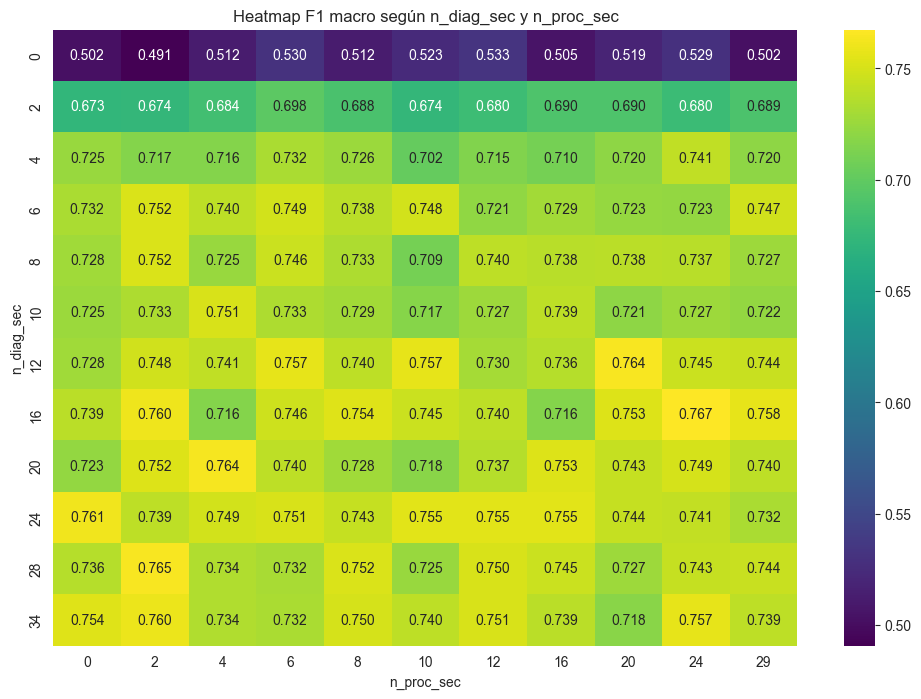

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

pivot_f1 = resultados_df.pivot(
    index="n_diag_sec",
    columns="n_proc_sec",
    values="f1_macro"
)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_f1, annot=True, fmt=".3f", cmap="viridis")
plt.title("Heatmap F1 macro según n_diag_sec y n_proc_sec")
plt.xlabel("n_proc_sec")
plt.ylabel("n_diag_sec")
plt.show()

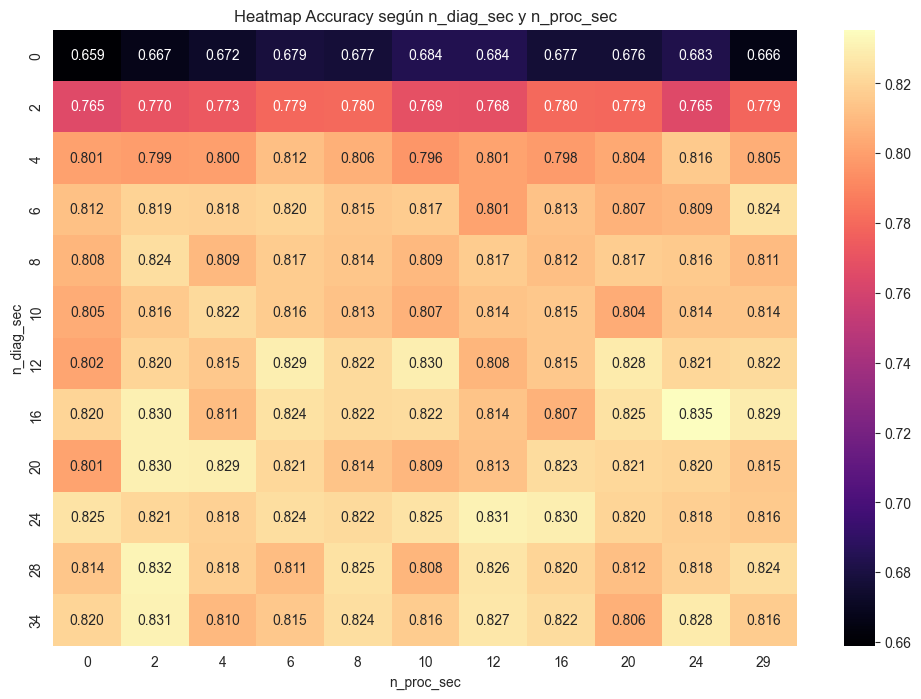

In [77]:
pivot_acc = resultados_df.pivot(
    index="n_diag_sec",
    columns="n_proc_sec",
    values="accuracy"
)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_acc, annot=True, fmt=".3f", cmap="magma")
plt.title("Heatmap Accuracy según n_diag_sec y n_proc_sec")
plt.xlabel("n_proc_sec")
plt.ylabel("n_diag_sec")
plt.show()

In [78]:
top10 = resultados_df.head(10).copy()
top10.to_csv("grid_search_top10.csv", index=False)

display(top10)

,n_diag_sec,n_proc_sec,n_diag_total_input,n_proc_total_input,n_inputs_total,n_classes,params,epochs_run,best_val_accuracy,best_val_loss,test_loss,accuracy,f1_macro,f1_weighted,top3_accuracy,seconds
0,16,24,17,25,44,113,333406,12,0.838868,0.629229,0.700732,0.835366,0.767344,0.832707,0.945993,13.67
1,28,2,29,3,34,113,298470,12,0.840501,0.626723,0.639820,0.831882,0.765035,0.829523,0.951655,11.42
2,12,20,13,21,36,113,304006,12,0.830158,0.653082,0.678081,0.828397,0.764287,0.824726,0.961672,14.90
3,20,4,21,5,28,113,283446,12,0.831247,0.680362,0.655011,0.829268,0.763957,0.826702,0.954268,9.88
4,24,0,25,1,28,113,276558,12,0.825803,0.716005,0.740469,0.825348,0.761230,0.822072,0.946429,10.02
5,16,2,17,3,22,113,261238,12,0.841045,0.667674,0.668896,0.830139,0.760103,0.824013,0.950784,8.69
6,34,2,35,3,40,113,312694,12,0.831247,0.692746,0.687967,0.830575,0.759607,0.827097,0.949477,13.02
7,16,29,17,30,49,113,347310,12,0.839956,0.661143,0.725210,0.828833,0.757551,0.821067,0.952091,15.05
8,12,10,13,11,26,113,272838,12,0.837235,0.649959,0.708794,0.829704,0.757455,0.827710,0.948606,16.19
9,12,6,13,7,22,113,258846,12,0.838868,0.664503,0.669465,0.829268,0.757101,0.824558,0.954704,15.51


---
## Random Forest
---

In [79]:
import os
import time
import json
import warnings
import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, top_k_accuracy_score
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")

top10 = pd.read_csv("grid_search_top10.csv")
display(top10)

,n_diag_sec,n_proc_sec,n_diag_total_input,n_proc_total_input,n_inputs_total,n_classes,params,epochs_run,best_val_accuracy,best_val_loss,test_loss,accuracy,f1_macro,f1_weighted,top3_accuracy,seconds
0,16,24,17,25,44,113,333406,12,0.838868,0.629229,0.700732,0.835366,0.767344,0.832707,0.945993,13.67
1,28,2,29,3,34,113,298470,12,0.840501,0.626723,0.639820,0.831882,0.765035,0.829523,0.951655,11.42
2,12,20,13,21,36,113,304006,12,0.830158,0.653082,0.678081,0.828397,0.764287,0.824726,0.961672,14.90
3,20,4,21,5,28,113,283446,12,0.831247,0.680362,0.655011,0.829268,0.763957,0.826702,0.954268,9.88
4,24,0,25,1,28,113,276558,12,0.825803,0.716005,0.740469,0.825348,0.761230,0.822072,0.946429,10.02
5,16,2,17,3,22,113,261238,12,0.841045,0.667674,0.668896,0.830139,0.760103,0.824013,0.950784,8.69
6,34,2,35,3,40,113,312694,12,0.831247,0.692746,0.687967,0.830575,0.759607,0.827097,0.949477,13.02
7,16,29,17,30,49,113,347310,12,0.839956,0.661143,0.725210,0.828833,0.757551,0.821067,0.952091,15.05
8,12,10,13,11,26,113,272838,12,0.837235,0.649959,0.708794,0.829704,0.757455,0.827710,0.948606,16.19
9,12,6,13,7,22,113,258846,12,0.838868,0.664503,0.669465,0.829268,0.757101,0.824558,0.954704,15.51


In [80]:
# =========================================================
# FASE 14 - CELDA 3
# Preparación de datos para Random Forest
# =========================================================

def preparar_configuracion_rf(df_base, n_diag_sec, n_proc_sec, random_state=42):
    diag_subset = diag_secundarios[:n_diag_sec]
    proc_subset = proc_secundarios[:n_proc_sec]

    cols_diag_sel = [col_diag_principal] + diag_subset
    cols_proc_sel = [col_proc_principal] + proc_subset

    cols_modelo = cols_diag_sel + cols_proc_sel + [col_edad, col_sexo, col_grd]
    df_feat = df_base[cols_modelo].copy()

    cols_codigos = cols_diag_sel + cols_proc_sel + [col_sexo]

    # faltantes
    for c in cols_codigos:
        df_feat[c] = df_feat[c].fillna("UNK")

    # split antes del encoding para evitar contaminación innecesaria
    X = df_feat.drop(columns=[col_grd]).copy()
    y = df_feat[col_grd].copy()

    X_train, X_test, y_train_raw, y_test_raw = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=random_state,
        stratify=y
    )

    # encoding por columna usando train como referencia
    encoders_x = {}
    for c in cols_codigos:
        le = LabelEncoder()

        valores_train = X_train[c].astype(str)
        valores_test = X_test[c].astype(str)

        le.fit(pd.concat([valores_train, valores_test], axis=0))
        X_train[c] = le.transform(valores_train)
        X_test[c] = le.transform(valores_test)

        encoders_x[c] = le

    # target encoding
    le_y = LabelEncoder()
    le_y.fit(pd.concat([y_train_raw.astype(str), y_test_raw.astype(str)], axis=0))

    y_train = le_y.transform(y_train_raw.astype(str))
    y_test = le_y.transform(y_test_raw.astype(str))

    return {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "le_y": le_y,
        "encoders_x": encoders_x,
        "cols_diag_sel": cols_diag_sel,
        "cols_proc_sel": cols_proc_sel
    }

In [81]:
# =========================================================
# FASE 14 - CELDA 4
# Entrenamiento y evaluación del modelo
# =========================================================

def ejecutar_experimento_rf(df_base, n_diag_sec, n_proc_sec, random_state=42):
    start = time.time()

    data = preparar_configuracion_rf(
        df_base=df_base,
        n_diag_sec=n_diag_sec,
        n_proc_sec=n_proc_sec,
        random_state=random_state
    )

    model = RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_split=4,
        min_samples_leaf=2,
        max_features="sqrt",
        bootstrap=True,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=random_state
    )

    model.fit(data["X_train"], data["y_train"])

    y_pred = model.predict(data["X_test"])
    y_pred_proba = model.predict_proba(data["X_test"])

    acc = accuracy_score(data["y_test"], y_pred)
    f1_macro = f1_score(data["y_test"], y_pred, average="macro")
    f1_weighted = f1_score(data["y_test"], y_pred, average="weighted")

    top3 = top_k_accuracy_score(
        data["y_test"],
        y_pred_proba,
        k=3,
        labels=np.arange(len(data["le_y"].classes_))
    )

    elapsed = time.time() - start

    return {
        "n_diag_sec": n_diag_sec,
        "n_proc_sec": n_proc_sec,
        "n_diag_total_input": len(data["cols_diag_sel"]),
        "n_proc_total_input": len(data["cols_proc_sel"]),
        "n_inputs_total": len(data["cols_diag_sel"]) + len(data["cols_proc_sel"]) + 2,
        "n_classes": len(data["le_y"].classes_),
        "accuracy": float(acc),
        "f1_macro": float(f1_macro),
        "f1_weighted": float(f1_weighted),
        "top3_accuracy": float(top3),
        "seconds": round(elapsed, 2)
    }

In [82]:

'''
HAY QUE CAMBIAR ESTO, TAL QUE TOME LAS MEJORES COMBINACIONES PARA SU CASO, 
NO LAS DE NN
'''

RF_RESULTS_CSV = "random_forest_top10_resultados.csv"
RF_RESULTS_JSON = "random_forest_top10_resultados.json"

resultados_rf = []

if os.path.exists(RF_RESULTS_CSV):
    prev = pd.read_csv(RF_RESULTS_CSV)
    resultados_rf = prev.to_dict(orient="records")
    ya_hechos = set(zip(prev["n_diag_sec"], prev["n_proc_sec"]))
    print(f"Se encontraron {len(prev)} resultados previos. Se continuará desde ahí.")
else:
    ya_hechos = set()
    print("No hay resultados previos. Se comenzará desde cero.")

for i, row in top10.iterrows():
    n_diag = int(row["n_diag_sec"])
    n_proc = int(row["n_proc_sec"])

    if (n_diag, n_proc) in ya_hechos:
        print(f"[SKIP] ya existe configuración diag={n_diag}, proc={n_proc}")
        continue

    print("=" * 80)
    print(f"Random Forest | Configuración {i+1}: diag={n_diag}, proc={n_proc}")
    print("=" * 80)

    try:
        res = ejecutar_experimento_rf(
            df_base=df_modelo,
            n_diag_sec=n_diag,
            n_proc_sec=n_proc,
            random_state=42
        )

        resultados_rf.append(res)

        df_temp = pd.DataFrame(resultados_rf).sort_values(
            by=["f1_macro", "accuracy", "f1_weighted"],
            ascending=False
        )

        df_temp.to_csv(RF_RESULTS_CSV, index=False)
        df_temp.to_json(RF_RESULTS_JSON, orient="records", indent=2)

        print({
            "accuracy": round(res["accuracy"], 4),
            "f1_macro": round(res["f1_macro"], 4),
            "f1_weighted": round(res["f1_weighted"], 4),
            "top3": round(res["top3_accuracy"], 4),
            "seconds": res["seconds"]
        })

    except Exception as e:
        print("ERROR:", e)
        continue

No hay resultados previos. Se comenzará desde cero.
Random Forest | Configuración 1: diag=16, proc=24
{'accuracy': 0.6559, 'f1_macro': 0.5274, 'f1_weighted': 0.6372, 'top3': 0.8994, 'seconds': 2.85}
Random Forest | Configuración 2: diag=28, proc=2
{'accuracy': 0.6751, 'f1_macro': 0.5791, 'f1_weighted': 0.6683, 'top3': 0.9107, 'seconds': 2.41}
Random Forest | Configuración 3: diag=12, proc=20
{'accuracy': 0.6747, 'f1_macro': 0.5562, 'f1_weighted': 0.6564, 'top3': 0.9103, 'seconds': 2.62}
Random Forest | Configuración 4: diag=20, proc=4
{'accuracy': 0.6816, 'f1_macro': 0.5843, 'f1_weighted': 0.6696, 'top3': 0.9203, 'seconds': 2.31}
Random Forest | Configuración 5: diag=24, proc=0
{'accuracy': 0.6912, 'f1_macro': 0.5992, 'f1_weighted': 0.6862, 'top3': 0.9111, 'seconds': 2.15}
Random Forest | Configuración 6: diag=16, proc=2
{'accuracy': 0.6834, 'f1_macro': 0.5877, 'f1_weighted': 0.6761, 'top3': 0.9194, 'seconds': 2.25}
Random Forest | Configuración 7: diag=34, proc=2
{'accuracy': 0.6799, 

In [83]:
# =========================================================
# FASE 14 - CELDA 6
# Ranking final Random Forest
# =========================================================

rf_resultados_df = pd.read_csv(RF_RESULTS_CSV)

rf_resultados_df = rf_resultados_df.sort_values(
    by=["f1_macro", "accuracy", "f1_weighted"],
    ascending=False
).reset_index(drop=True)

display(rf_resultados_df)

,n_diag_sec,n_proc_sec,n_diag_total_input,n_proc_total_input,n_inputs_total,n_classes,accuracy,f1_macro,f1_weighted,top3_accuracy,seconds
0,24,0,25,1,28,113,0.691202,0.599162,0.686204,0.911150,2.15
1,16,2,17,3,22,113,0.683362,0.587688,0.676053,0.919425,2.25
2,20,4,21,5,28,113,0.681620,0.584268,0.669568,0.920296,2.31
3,34,2,35,3,40,113,0.679878,0.583853,0.673641,0.908972,2.13
4,12,6,13,7,22,113,0.687718,0.581311,0.673931,0.925087,2.16
5,28,2,29,3,34,113,0.675087,0.579105,0.668306,0.910714,2.41
6,12,10,13,11,26,113,0.686411,0.578297,0.669897,0.925523,2.74
7,12,20,13,21,36,113,0.674652,0.556248,0.656378,0.910279,2.62
8,16,29,17,30,49,113,0.664634,0.545587,0.646454,0.902003,2.52
9,16,24,17,25,44,113,0.655923,0.527410,0.637153,0.899390,2.85


In [84]:
mejor_rf = rf_resultados_df.iloc[0]

print("Mejor configuración Random Forest:")
print(mejor_rf)

Mejor configuración Random Forest:
n_diag_sec             24.000000
n_proc_sec              0.000000
n_diag_total_input     25.000000
n_proc_total_input      1.000000
n_inputs_total         28.000000
n_classes             113.000000
accuracy                0.691202
f1_macro                0.599162
f1_weighted             0.686204
top3_accuracy           0.911150
seconds                 2.150000
Name: 0, dtype: float64


In [85]:
# =========================================================
# FASE 14 - CELDA 8
# Comparación con la red neuronal sobre las mismas configuraciones
# =========================================================

nn_top10 = top10[[
    "n_diag_sec",
    "n_proc_sec",
    "accuracy",
    "f1_macro",
    "f1_weighted",
    "top3_accuracy"
]].copy()

comparacion_tecnicas = rf_resultados_df.merge(
    nn_top10,
    on=["n_diag_sec", "n_proc_sec"],
    suffixes=("_rf", "_nn")
)

display(comparacion_tecnicas)

,n_diag_sec,n_proc_sec,n_diag_total_input,n_proc_total_input,n_inputs_total,n_classes,accuracy_rf,f1_macro_rf,f1_weighted_rf,top3_accuracy_rf,seconds,accuracy_nn,f1_macro_nn,f1_weighted_nn,top3_accuracy_nn
0,24,0,25,1,28,113,0.691202,0.599162,0.686204,0.911150,2.15,0.825348,0.761230,0.822072,0.946429
1,16,2,17,3,22,113,0.683362,0.587688,0.676053,0.919425,2.25,0.830139,0.760103,0.824013,0.950784
2,20,4,21,5,28,113,0.681620,0.584268,0.669568,0.920296,2.31,0.829268,0.763957,0.826702,0.954268
3,34,2,35,3,40,113,0.679878,0.583853,0.673641,0.908972,2.13,0.830575,0.759607,0.827097,0.949477
4,12,6,13,7,22,113,0.687718,0.581311,0.673931,0.925087,2.16,0.829268,0.757101,0.824558,0.954704
5,28,2,29,3,34,113,0.675087,0.579105,0.668306,0.910714,2.41,0.831882,0.765035,0.829523,0.951655
6,12,10,13,11,26,113,0.686411,0.578297,0.669897,0.925523,2.74,0.829704,0.757455,0.827710,0.948606
7,12,20,13,21,36,113,0.674652,0.556248,0.656378,0.910279,2.62,0.828397,0.764287,0.824726,0.961672
8,16,29,17,30,49,113,0.664634,0.545587,0.646454,0.902003,2.52,0.828833,0.757551,0.821067,0.952091
9,16,24,17,25,44,113,0.655923,0.527410,0.637153,0.899390,2.85,0.835366,0.767344,0.832707,0.945993


In [86]:
diag_cols = [c for c in df_modelo.columns if "diag" in c.lower()]
proc_cols = [c for c in df_modelo.columns if "proc" in c.lower() or "proced" in c.lower()]

col_diag_principal = [c for c in diag_cols if "principal" in c.lower()][0]
col_proc_principal = [c for c in proc_cols if "principal" in c.lower()][0]

diag_secundarios = sorted([c for c in diag_cols if "secundario" in c.lower()])
proc_secundarios = sorted([c for c in proc_cols if "secundario" in c.lower()])

col_edad = "Edad en años"
col_sexo = "Sexo (Desc)"
col_grd = "GRD"

cfg_A = {"nombre": "A_16_24", "n_diag_sec": 16, "n_proc_sec": 24}

print(cfg_A)

{'nombre': 'A_16_24', 'n_diag_sec': 16, 'n_proc_sec': 24}


In [87]:
def limpiar_nombre_capa(nombre):
    nombre = str(nombre).strip().lower()
    nombre = nombre.replace(" ", "_")
    nombre = nombre.replace("(", "")
    nombre = nombre.replace(")", "")
    nombre = nombre.replace("/", "_")
    nombre = nombre.replace("-", "_")
    nombre = nombre.replace(".", "_")
    nombre = re.sub(r"[^a-zA-Z0-9_]", "", nombre)
    return nombre

def reset_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)